# Zero-shot cell-type annotation with UniGeneX

This tutorial maps held-out Human Lung Cell Atlas (HLCA) query cells to the UniGeneX universal gene expression (UGE) atlas. It reproduces the atlas projection in Figure 2B and the lineage-level annotation results in Figure 2C of the UniGeneX manuscript.

Processed inputs and mapping results are available from the [UniGeneX Zenodo deposit](https://doi.org/10.5281/zenodo.19750490). The concept DOI resolves to the latest public version; use the version-specific DOI shown by Zenodo when citing an exact release.

## Data and directory layout

Download and extract Training_output.zip, Training_input.zip, and Training_input_testdata.zip from Zenodo. This notebook expects:

    reproducibility/
    ├── Training_output/
    │   ├── atlas_1e3_maskp5_processed.h5ad
    │   ├── Testdata_UGE.h5ad
    │   └── NN_mapped_results/
    │       └── query_to_atlas_mapping.h5ad
    ├── Training_input/
    │   └── obs_concat.csv
    └── Training_input_testdata/
        └── obs_concat.csv

Set `UNIGENEX_REPRO_DATA` to the reproducibility directory. If it is unset, the notebook looks for `data/` under the repository root. `Testdata_UGE.h5ad` is required only when regenerating the mapping; the remaining analysis uses the precomputed compact result.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import NearestNeighbors

REPOSITORY_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "UniGeneX").is_dir()
)
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

from UniGeneX.mapping import (
    AtlasMapper, align_atlas_to_mapping, validate_mapping_result,
)
from UniGeneX.plotting import plot_atlas_projection

DATA_ROOT = Path(os.environ.get(
    "UNIGENEX_REPRO_DATA", REPOSITORY_ROOT / "data",
)).expanduser().resolve()

ATLAS_PATH = DATA_ROOT / "Training_output" / "atlas_1e3_maskp5_processed.h5ad"
QUERY_PATH = DATA_ROOT / "Training_output" / "Testdata_UGE.h5ad"
ATLAS_INDEX_PATH = DATA_ROOT / "Training_output" / "NN_atlas_1e3_maskp5"
MAPPING_PATH = DATA_ROOT / "Training_output" / "NN_mapped_results" / "query_to_atlas_mapping.h5ad"
ATLAS_METADATA_PATH = DATA_ROOT / "Training_input" / "obs_concat.csv"
QUERY_METADATA_PATH = DATA_ROOT / "Training_input_testdata" / "obs_concat.csv"

LABEL_COLUMN = "ann_finest_level"
PREDICTION_COLUMN = f"predict_mapped_{LABEL_COLUMN}"
CONFIDENCE_COLUMN = f"{PREDICTION_COLUMN}_prob"

plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_context("paper")

## Generate the mapping (optional)

The following cell demonstrates the complete Python API used to map the held-out query data. The distributed notebook keeps `RUN_MAPPING = False` and loads the precomputed Zenodo result, allowing the figures to be reproduced without repeating this long-running step. Set it to `True` only when the atlas and query UGE files are available and a new mapping is required.

In [2]:
RUN_MAPPING = False

if RUN_MAPPING:
    atlas_for_mapping = sc.read_h5ad(ATLAS_PATH)
    query_for_mapping = sc.read_h5ad(QUERY_PATH)

    mapper = AtlasMapper(
        atlas_for_mapping,
        LABEL_COLUMN,
        n_neighbors=30,
        keep_unlabeled_atlas=False,
    ).fit(recompute_pca=True)
    mapping_adata = mapper.map(query_for_mapping)

    mapper.save_index(ATLAS_INDEX_PATH)
    MAPPING_PATH.parent.mkdir(parents=True, exist_ok=True)
    mapping_adata.write_h5ad(MAPPING_PATH)
    del mapper, atlas_for_mapping, query_for_mapping
else:
    print("Using the precomputed mapping. Set RUN_MAPPING=True to regenerate it.")

Using the precomputed mapping. Set RUN_MAPPING=True to regenerate it.


### Command-line version

For large datasets, the non-interactive shell workflow is recommended:

```bash
cd UniGeneX/05_UGE_celltype_annotation
bash transformer_map_to_atlas.sh
```

The shell script defines the input and output paths and calls `transformer_map_to_atlas.py`. That Python file is a thin command-line interface around the same `AtlasMapper.fit()`, `AtlasMapper.map()`, and `AtlasMapper.save_index()` methods shown above.

## Load and validate the compact mapping result

The mapping H5AD contains a sparse query-to-atlas connectivity matrix rather than a second expression matrix. Matrix rows follow obs_names (query cells), and columns follow var_names (atlas cells). Neighbor indices in obsm therefore refer to positions in var_names.

In [3]:
atlas_adata = sc.read_h5ad(ATLAS_PATH, backed="r")
if not RUN_MAPPING:
    mapping_adata = sc.read_h5ad(MAPPING_PATH)
atlas_metadata = pd.read_csv(ATLAS_METADATA_PATH, index_col=0, low_memory=False)
query_metadata = pd.read_csv(QUERY_METADATA_PATH, index_col=0, low_memory=False)

validate_mapping_result(
    mapping_adata, expected_neighbors=30, require_unique_query=True
)

missing_atlas_metadata = atlas_adata.obs_names.difference(atlas_metadata.index)
if len(missing_atlas_metadata):
    raise ValueError(f"Metadata are missing for {len(missing_atlas_metadata)} atlas cells.")
atlas_adata.obs["ann_level_3"] = atlas_metadata.loc[atlas_adata.obs_names, "ann_level_3"].copy()

atlas_adata = align_atlas_to_mapping(atlas_adata, mapping_adata)

if not mapping_adata.obs_names.equals(query_metadata.index):
    raise ValueError("Query metadata rows and mapping rows are not aligned.")
query_columns = [
    LABEL_COLUMN,
    "dataset",
    "ann_level_1",
    "disease",
    "original_ann_nonharmonized",
    "ann_level_3",
]
missing_query_columns = [column for column in query_columns if column not in query_metadata]
if missing_query_columns:
    raise ValueError(f"Missing query metadata columns: {missing_query_columns}")
mapping_adata.obs[query_columns] = query_metadata.loc[mapping_adata.obs_names, query_columns].copy()

for column in [PREDICTION_COLUMN, CONFIDENCE_COLUMN]:
    if column not in mapping_adata.obs:
        raise ValueError(f"Missing mapping result column: {column}")

atlas_labels = atlas_adata.obs[LABEL_COLUMN].astype("category")
color_dict = dict(zip(
    atlas_labels.cat.categories,
    atlas_adata.uns[f"{LABEL_COLUMN}_colors"],
))

print(f"Query cells: {mapping_adata.n_obs:,}")
print(f"Atlas cells: {mapping_adata.n_vars:,}")
n_neighbors = mapping_adata.obsm["atlas_neighbor_indices"].shape[1]
print(f"Neighbors per query cell: {n_neighbors}")

Query cells: 157,968
Atlas cells: 607,328
Neighbors per query cell: 30


The compact file stores:

- X: query-to-atlas UMAP fuzzy connectivities.
- obs: query identifiers, predicted labels and mapping confidence.
- var: atlas identifiers and the label used for transfer.
- obsm: atlas-neighbor indices and cosine distances.
- uns: matrix semantics and mapping parameters.

In [4]:
X_umap = atlas_adata.obsm["X_umap"]

## Figure 2B: projection onto the UGE atlas

Atlas cells are shown in gray. Held-out query cells are positioned by their connectivity-weighted atlas UMAP coordinates and colored by their transferred fine cell-type annotation.

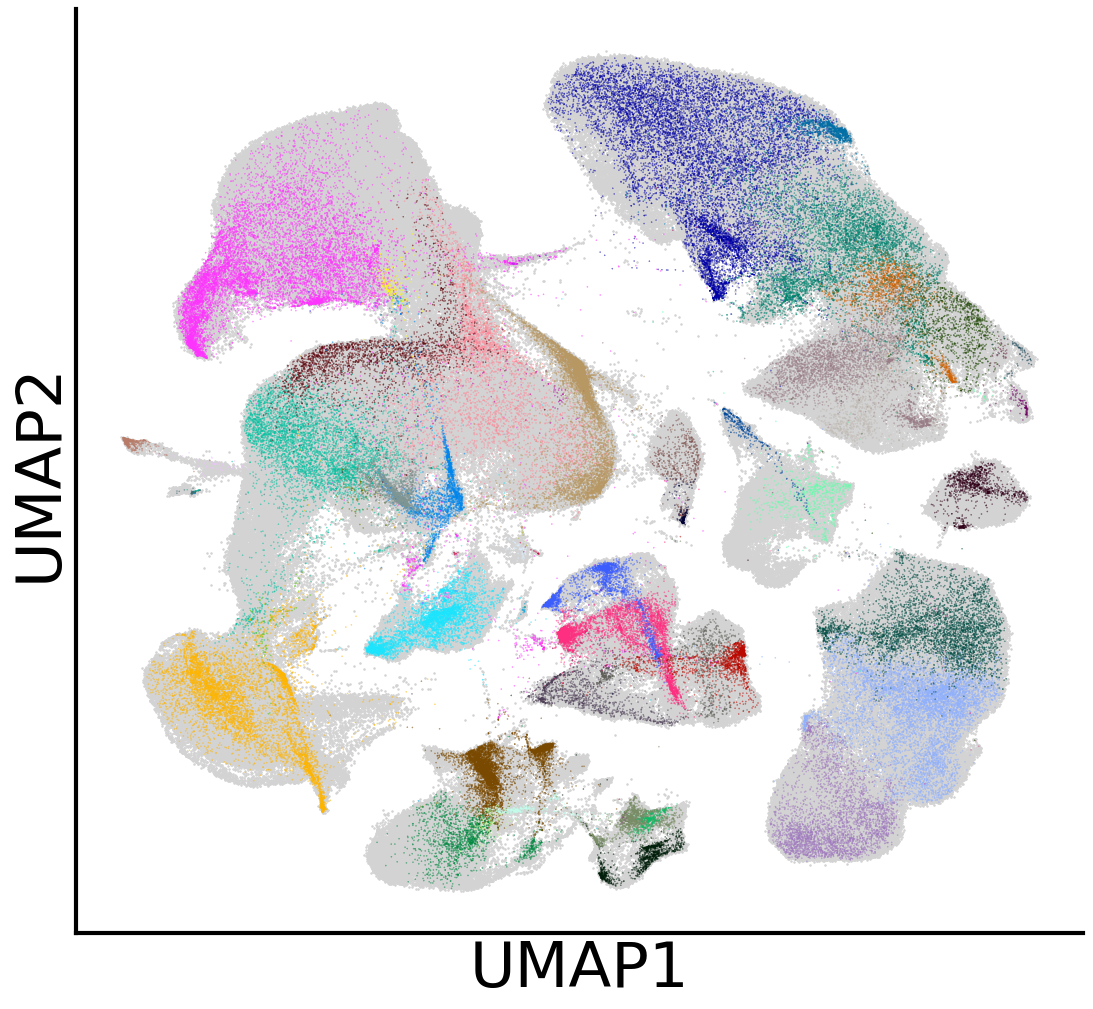

In [5]:
query_colors = np.array([
    color_dict.get(label, "lightgray")
    for label in mapping_adata.obs[PREDICTION_COLUMN]
])

fig, ax = plot_atlas_projection(
    mapping_adata,
    X_umap,
    atlas_labels,
    query_colors,
    groups=atlas_labels.value_counts().index,
    connectivity_threshold=0.5,
    display_quantile=0.3,
)

ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("UMAP1", fontsize=45)
ax.set_ylabel("UMAP2", fontsize=45)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("black")
    ax.spines[spine].set_linewidth(3)
plt.show()
plt.close(fig)

## Figure 2C: lineage-level annotation

Evaluation follows the manuscript workflow: cells with missing or Unknown reference annotations are removed; cell types must contain at least 25 cells within a held-out dataset; and predictions must have mapping confidence greater than 0.5. Schultze_unpubl and Shalek_2018 are excluded from the reported nine-dataset benchmark.

In [6]:
evaluation = mapping_adata.obs[[
    LABEL_COLUMN,
    PREDICTION_COLUMN,
    CONFIDENCE_COLUMN,
    "dataset",
]].copy()
evaluation = evaluation.rename(columns={
    PREDICTION_COLUMN: "predictions",
    CONFIDENCE_COLUMN: "confidence",
    "dataset": "data_file_names",
})

evaluation = evaluation.loc[evaluation[LABEL_COLUMN].notna()]
evaluation = evaluation.loc[evaluation[LABEL_COLUMN] != "Unknown"]
cell_type_counts = evaluation.groupby(
    ["data_file_names", LABEL_COLUMN], observed=True
)[LABEL_COLUMN].transform("size")
evaluation = evaluation.loc[cell_type_counts >= 25]
evaluation = evaluation.loc[evaluation["confidence"] > 0.5]

evaluation_exclusions = ["Schultze_unpubl", "Shalek_2018"]
evaluation = evaluation.loc[
    ~evaluation["data_file_names"].isin(evaluation_exclusions)
].copy()

print(f"Evaluated cells: {evaluation.shape[0]:,}")
print(f"Held-out datasets: {evaluation['data_file_names'].nunique()}")

Evaluated cells: 119,644
Held-out datasets: 9


### Lineage confusion matrices

Rows are reference annotations and columns are UniGeneX predictions. Each represented row is normalized to sum to one.

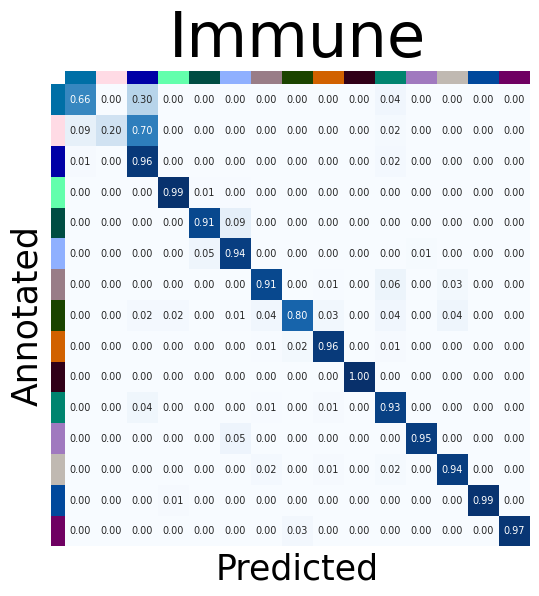

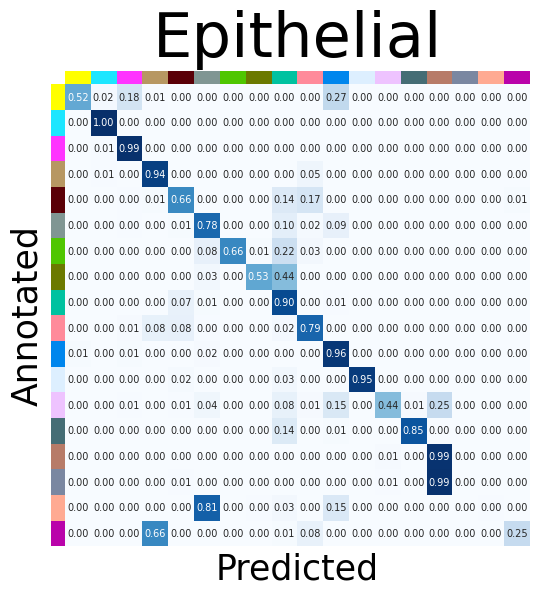

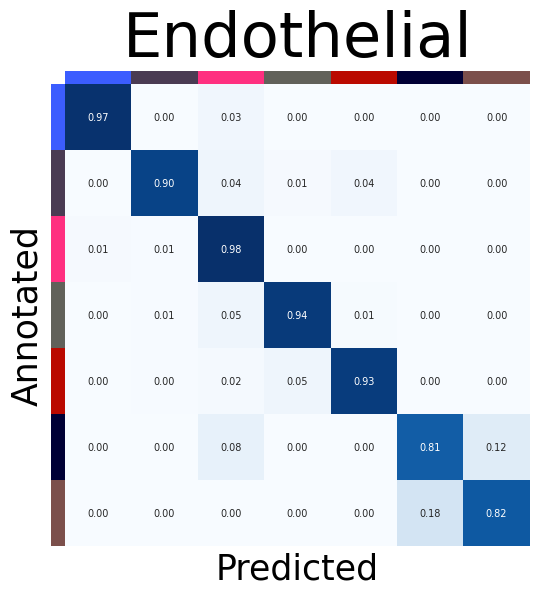

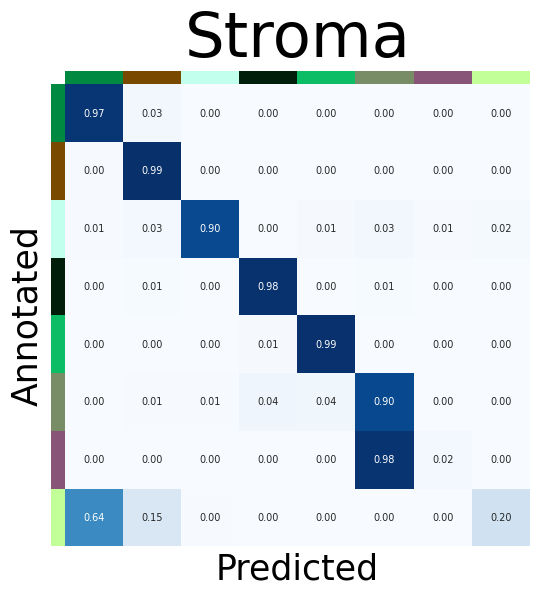

In [7]:
lineage_groups = {
    "Immune": [
        "Alveolar Mph CCL3+", "Alveolar Mph MT-positive", "Alveolar Mph proliferating",
        "Alveolar macrophages", "B cells", "CD4 T cells", "CD8 T cells",
        "Classical monocytes", "DC1", "DC2", "Interstitial Mph perivascular",
        "Mast cells", "Migratory DCs", "Monocyte-derived Mph", "NK cells",
        "Non-classical monocytes", "Plasma cells", "Plasmacytoid DCs",
        "T cells proliferating",
    ],
    "Epithelial": [
        "AT0", "AT1", "AT2", "Basal resting", "Club (nasal)", "Club (non-nasal)",
        "Deuterosomal", "Goblet (bronchial)", "Goblet (nasal)", "Suprabasal",
        "pre-TB secretory", "Ionocyte", "Mesothelium", "SMG duct", "SMG mucous",
        "SMG serous (bronchial)", "SMG serous (nasal)", "Goblet (subsegmental)",
        "Hillock-like",
    ],
    "Endothelial": [
        "EC aerocyte capillary", "EC arterial", "EC general capillary",
        "EC venous pulmonary", "EC venous systemic", "Lymphatic EC differentiating",
        "Lymphatic EC mature",
    ],
    "Stroma": [
        "Adventitial fibroblasts", "Alveolar fibroblasts", "Myofibroblasts",
        "Pericytes", "SM activated stress response", "Smooth muscle",
        "Smooth muscle FAM83D+", "Peribronchial fibroblasts",
    ],
}

label_aliases = {
    "Multiciliated (non-nasal)": "Multiciliated",
    "Multiciliated (nasal)": "Multiciliated",
}

for lineage, cell_types in lineage_groups.items():
    true_labels = evaluation[LABEL_COLUMN].astype(object).replace(label_aliases)
    predicted_labels = evaluation["predictions"].astype(object).replace(label_aliases)
    included = true_labels.isin(cell_types) & predicted_labels.isin(cell_types)

    matrix = confusion_matrix(
        true_labels[included],
        predicted_labels[included],
        labels=cell_types,
    )
    represented = matrix.sum(axis=1) > 10
    matrix = matrix[represented][:, represented].astype(float)
    matrix /= matrix.sum(axis=1, keepdims=True)
    displayed_types = np.asarray(cell_types)[represented]

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        pd.DataFrame(matrix, index=displayed_types, columns=displayed_types),
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        annot_kws={"size": 7},
        ax=ax,
    )
    for index, cell_type in enumerate(displayed_types):
        color = color_dict[cell_type]
        ax.add_patch(plt.Rectangle(
            (-0.03, index), 0.03, 1, color=color, lw=0,
            transform=ax.get_yaxis_transform(), clip_on=False,
        ))
        ax.add_patch(plt.Rectangle(
            (index, 1), 1, 0.03, color=color, lw=0,
            transform=ax.get_xaxis_transform(), clip_on=False,
        ))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(lineage, fontsize=45, pad=20)
    ax.set_xlabel("Predicted", fontsize=25)
    ax.set_ylabel("Annotated", fontsize=25, labelpad=15)
    plt.show()
    plt.close(fig)

### Annotated and predicted lineage UMAPs

For each lineage, query cells are shown once using transferred labels and once using held-out reference annotations. Atlas outliers are removed only from the gray visualization background.

Immune: Predicted


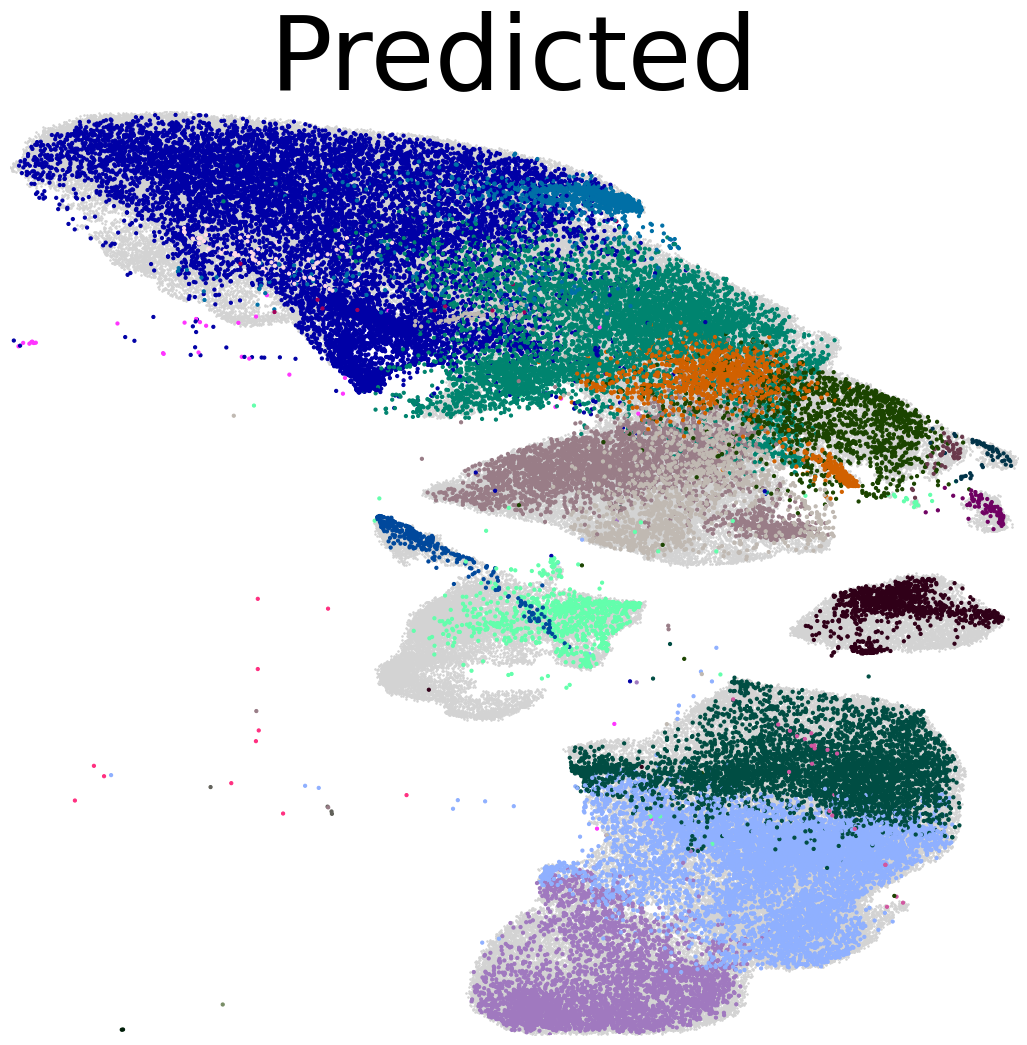

Immune: Annotated


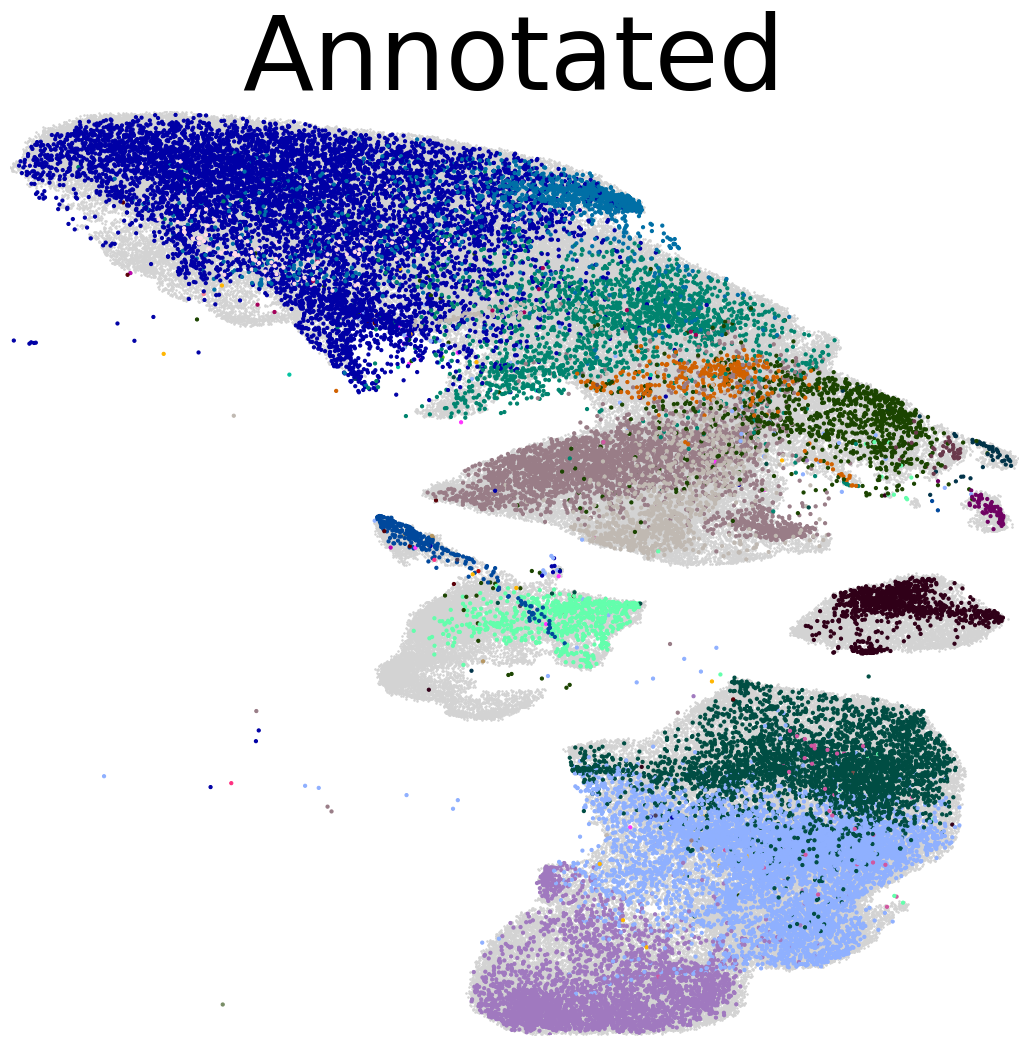

Epithelial: Predicted


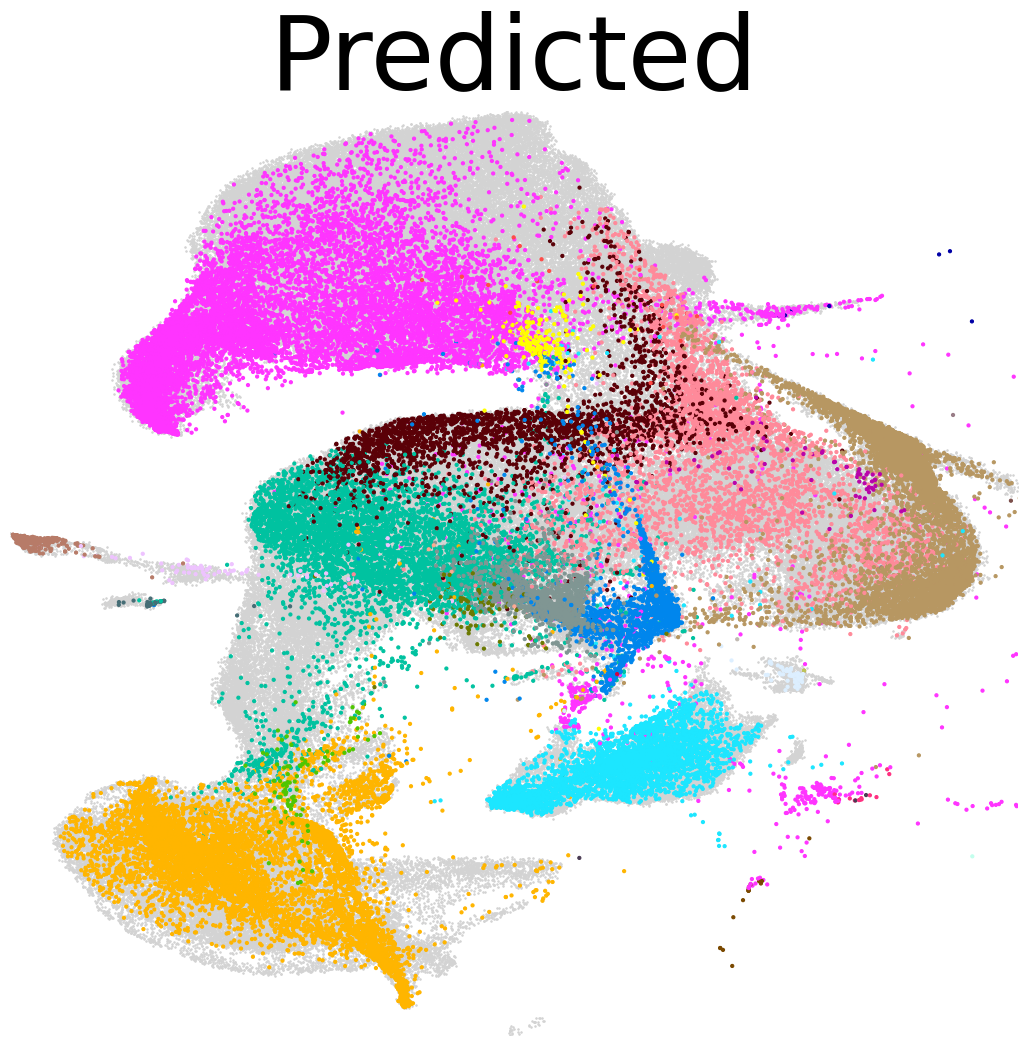

Epithelial: Annotated


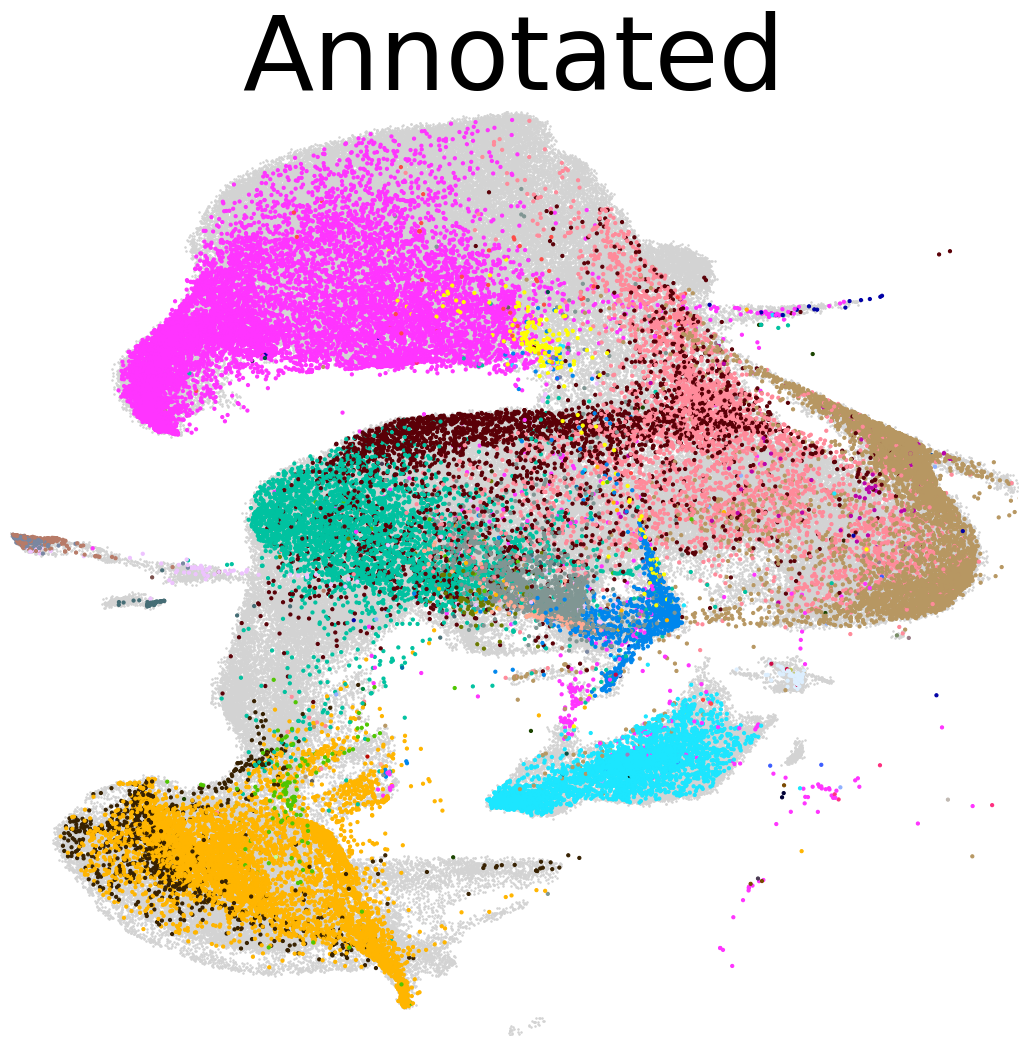

Endothelial: Predicted


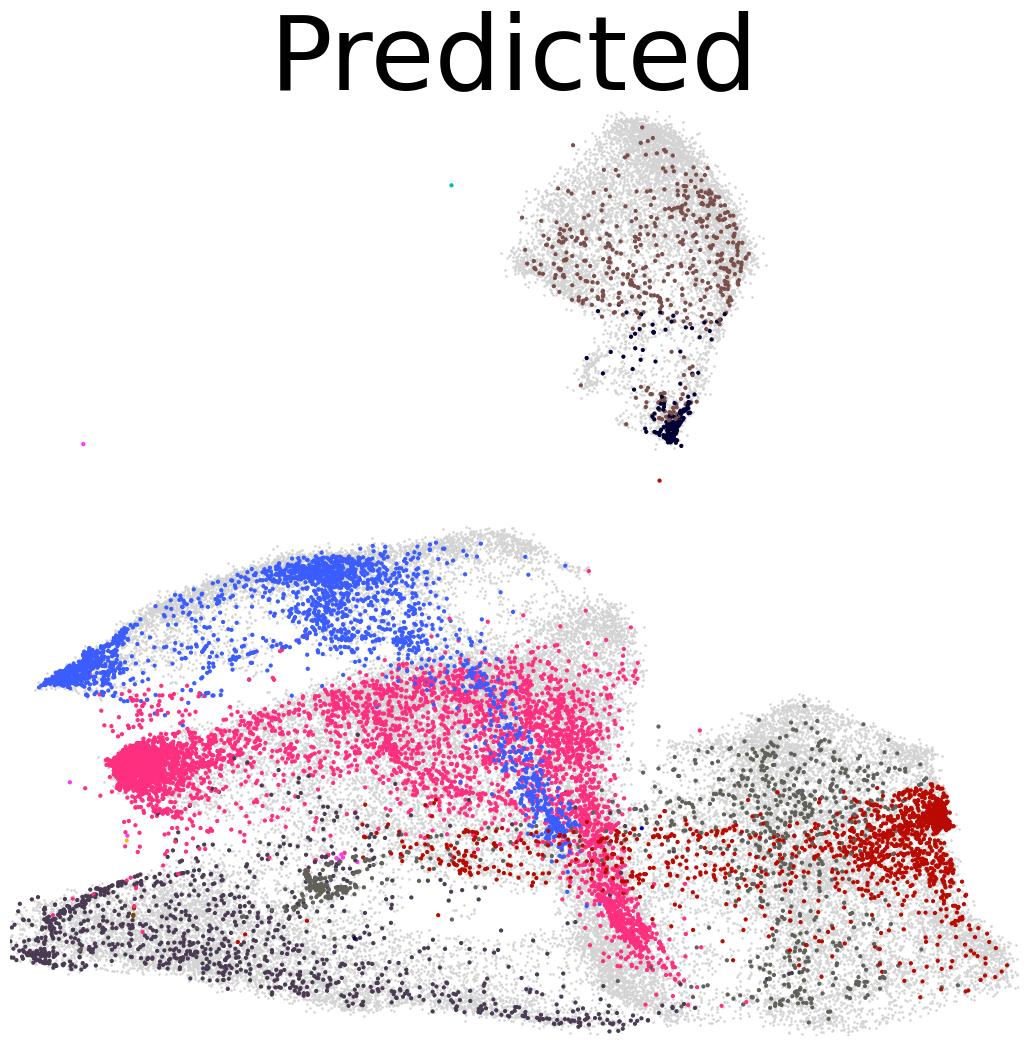

Endothelial: Annotated


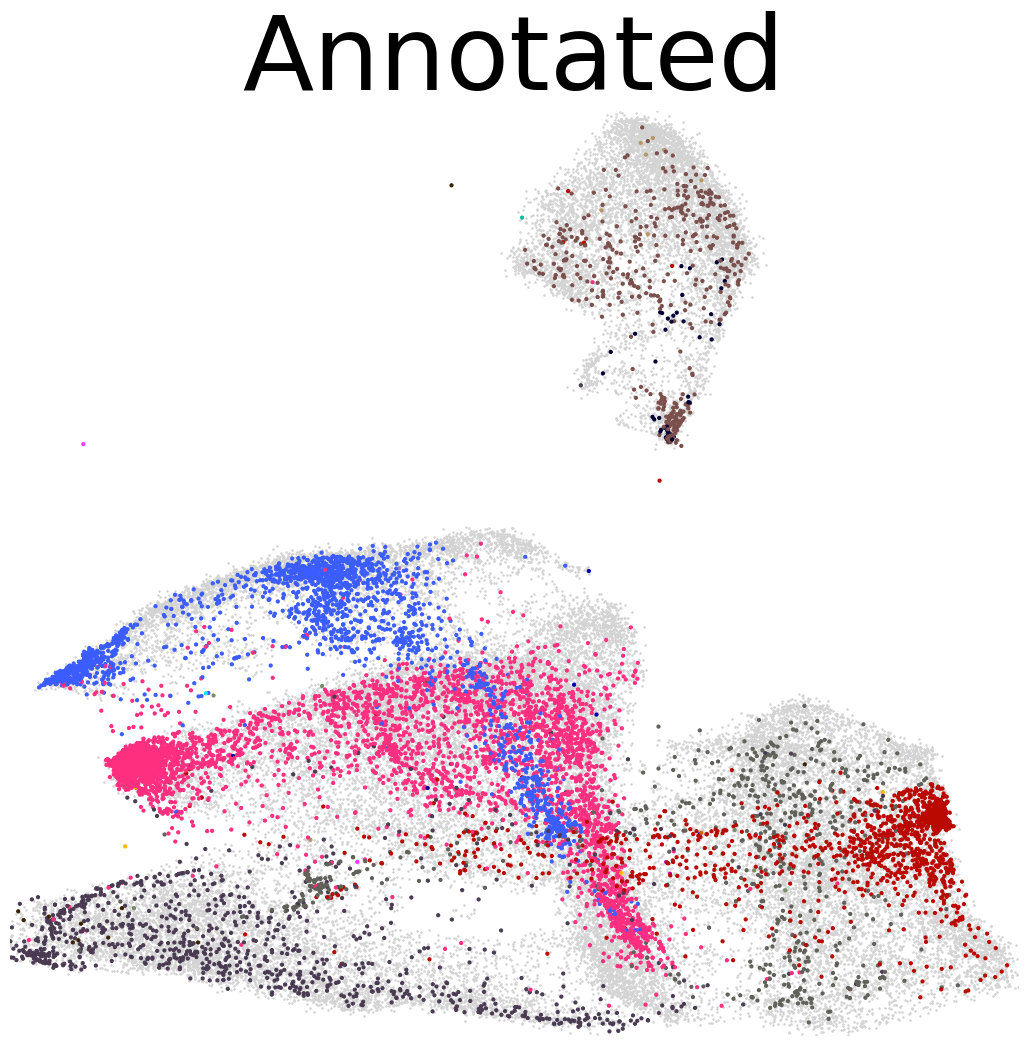

Stroma: Predicted


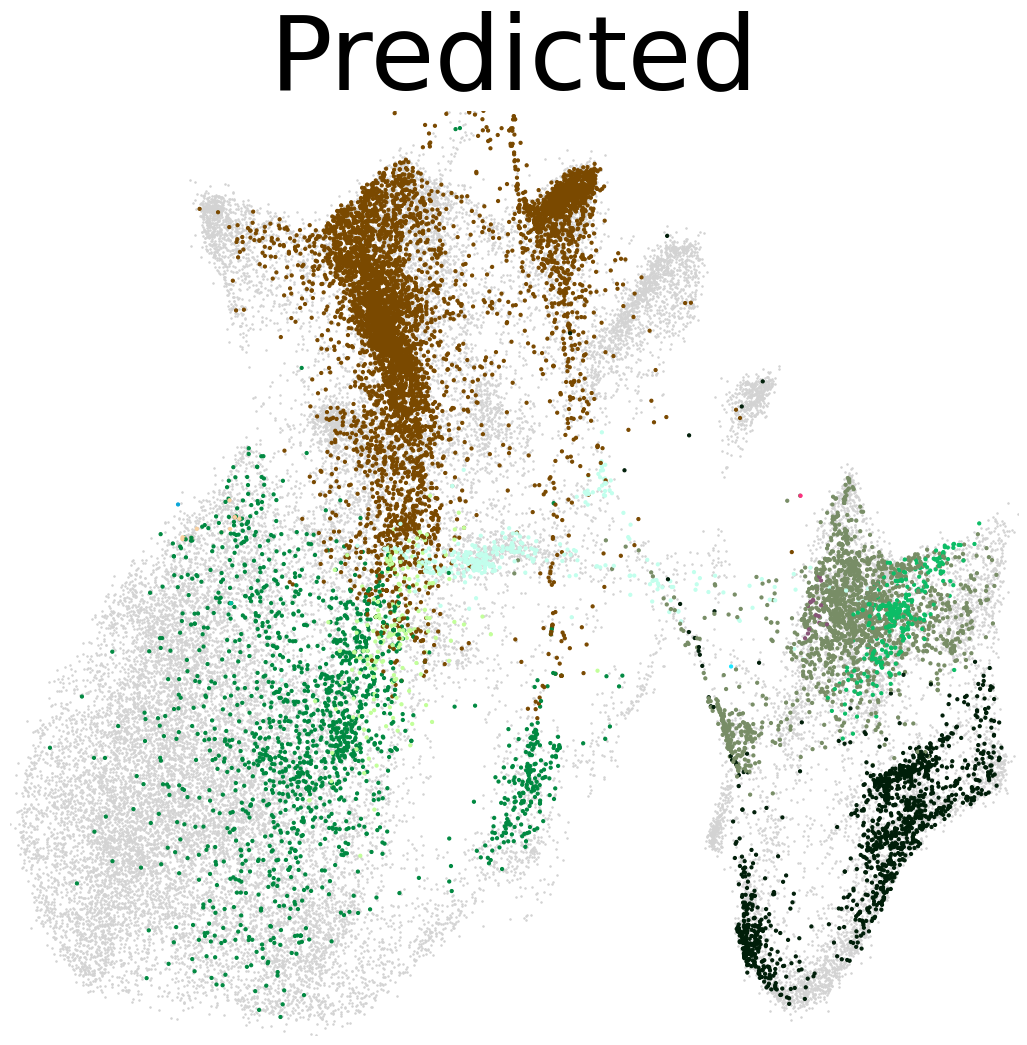

Stroma: Annotated


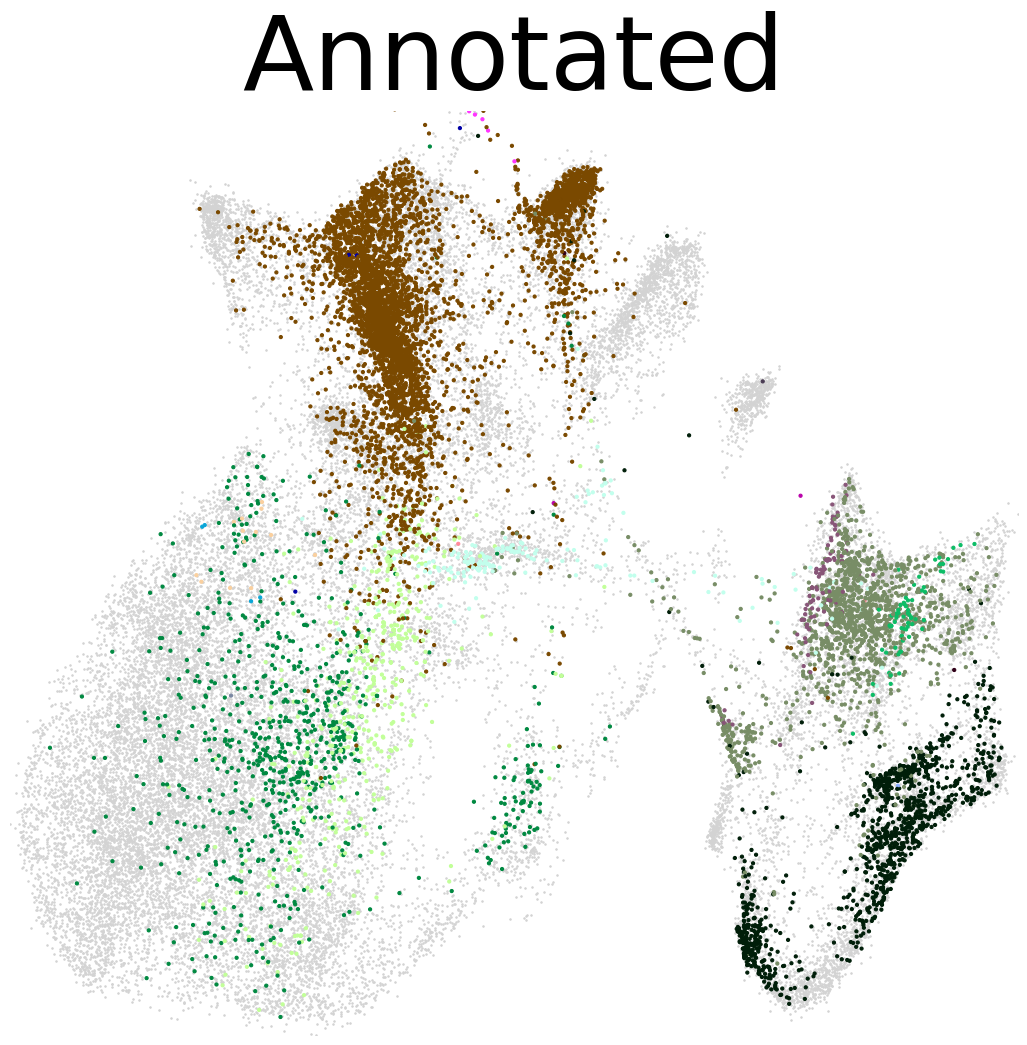

In [8]:
macrophage_types = [
    "Alveolar macrophages", "Monocyte-derived Mph", "Classical monocytes",
    "Non-classical monocytes", "DC2", "Interstitial Mph perivascular",
    "Alveolar Mph CCL3+", "Alveolar Mph MT-positive", "Alveolar Mph proliferating",
    "Plasmacytoid DCs", "Migratory DCs", "DC1",
]
t_nk_types = ["NK cells", "CD8 T cells", "CD4 T cells", "T cells proliferating"]
b_mast_types = ["B cells", "Mast cells", "Plasma cells"]
epithelial_types = [
    "AT2", "Goblet (nasal)", "Multiciliated (non-nasal)", "Suprabasal",
    "Club (nasal)", "Basal resting", "AT1", "Hillock-like", "pre-TB secretory",
    "Club (non-nasal)", "Goblet (bronchial)", "Ionocyte", "Deuterosomal", "AT0",
    "SMG duct", "AT2 proliferating", "SMG serous (bronchial)", "SMG mucous",
    "SMG serous (nasal)", "Mesothelium", "Goblet (subsegmental)",
    "Multiciliated (nasal)", "Neuroendocrine", "Tuft",
]
fibroblast_types = [
    "Adventitial fibroblasts", "Alveolar fibroblasts", "Peribronchial fibroblasts",
    "Myofibroblasts", "Subpleural fibroblasts",
]
endothelial_types = [
    "EC general capillary", "EC arterial", "Lymphatic EC mature",
    "EC venous pulmonary", "EC aerocyte capillary", "EC venous systemic",
    "Lymphatic EC differentiating", "Lymphatic EC proliferating",
]
smooth_muscle_types = [
    "Pericytes", "Smooth muscle", "SM activated stress response",
    "Smooth muscle FAM83D+",
]

lineage_umap_groups = {
    "Immune": macrophage_types + t_nk_types + b_mast_types,
    "Epithelial": epithelial_types,
    "Endothelial": endothelial_types,
    "Stroma": fibroblast_types + smooth_muscle_types,
}


def atlas_outliers(coordinates, quantile=0.99):
    model = NearestNeighbors(n_neighbors=30).fit(coordinates)
    distances, _ = model.kneighbors(coordinates)
    mean_distance = distances.mean(axis=1)
    return mean_distance > np.quantile(mean_distance, quantile)


for lineage, cell_types in lineage_umap_groups.items():
    atlas_lineage_mask = atlas_adata.obs[LABEL_COLUMN].isin(cell_types).to_numpy()
    atlas_coordinates = X_umap[atlas_lineage_mask]
    atlas_coordinates = atlas_coordinates[~atlas_outliers(atlas_coordinates)]

    for view, title in [("predicted", "Predicted"), ("annotated", "Annotated")]:
        if view == "predicted":
            query_labels = mapping_adata.obs[PREDICTION_COLUMN]
        else:
            query_labels = mapping_adata.obs[LABEL_COLUMN]

        query_colors = np.array([
            color_dict.get(label, "lightgray") for label in query_labels
        ])
        visible_query = query_labels.notna().to_numpy() & query_labels.ne("Unknown").to_numpy()

        fig, ax = plot_atlas_projection(
            mapping_adata,
            X_umap,
            atlas_labels,
            query_colors,
            groups=cell_types,
            query_mask=visible_query,
            background_coordinates=atlas_coordinates,
            connectivity_threshold=0.5,
            display_quantile=0.3,
            min_points=30,
            query_size=5.0,
        )

        ax.grid(False)
        ax.set_title(title, fontsize=75)
        ax.set_xlim(atlas_coordinates[:, 0].min(), atlas_coordinates[:, 0].max())
        ax.set_ylim(atlas_coordinates[:, 1].min(), atlas_coordinates[:, 1].max())
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        for spine in ax.spines.values():
            spine.set_visible(False)
        print(f"{lineage}: {title}")
        plt.show()
        plt.close(fig)

## Interpretation

Figure 2B visualizes whether held-out query cells project into the expected regions of the UGE atlas. Figure 2C compares transferred and reference annotations within immune, epithelial, endothelial and stromal lineages. The confusion matrices summarize label agreement, while the paired UMAPs show where disagreements occur in the atlas manifold.